# ICT-10 — Grammaire des catastrophes : *l'obstacle qui engendre les formes, le verbe qui les fait basculer*

> **Serie ICT** (Integrated Causal Trajectories, Epic #4588) — **charniere strate 2 -> strate 3**.
> Prerequis conseilles : [ICT-0-Framing](ICT-0-Framing.md), [ICT-8](ICT-8-AttractorLandscapesEWS.ipynb)
> (paysages d'attracteurs, pli, ralentissement critique) et [ICT-9](ICT-9-AgencyRegeneration.ipynb)
> (agence comme reparation mesuree).

## Un prelude a Rene Thom — mais *sans complaisance*

Ce notebook est le **prelude semiophysique** de la serie : il introduit le vocabulaire de Rene Thom
(*Esquisse d'une semiophysique*, 1991 ; *Stabilite structurelle et morphogenese*, 1972) — **saillance,
pregnance, catastrophe, actant** — mais en respectant la regle de la serie : *aucun concept n'entre dans
ICT tant qu'il n'est pas attache a une mesure, une intervention ou un contraste*. La theorie des
catastrophes a une mauvaise reputation (« metaphore qualitative ») precisement quand on l'invoque sans
rien mesurer. Ici, **chaque image de Thom est adossee a une grandeur calculee** sur la catastrophe
canonique, la **fronce** (*cusp*).

## Les deux fils, tresses

| Fil | Concept de Thom | Ce qu'on mesure |
|---|---|---|
| **A. Le metatheoreme** (ferme la strate 2) | *« l'obstacle comme source de l'ontologie »* (Ch.3) | le **nombre d'equilibres** ne change qu'aux **plis** — naissance/disparition d'une paire |
| **B. Le lacet de predation** (ouvre la strate 3) | la **scene actantielle** predateur/proie (Ch.4) | un **cycle d'hysteresis** a **deux** catastrophes (perception J, capture K) + un **representant interne** `p_hat` qui anticipe |

## La surprise du chapitre 2 (« Le Langage »)

En relisant Thom de pres, les objets qu'on mesure ici se revelent etre **ses propres modeles
linguistiques** (Ch.2, pp.35-52) :

- les **quatre transitions generiques** du metatheoreme (debut, fin, ramification, confluence)
  *« symbolisent adequatement le contenu »* des premiers pivots du langage enfantin (p.38) ;
- la **phrase transitive SVO** (« le chat mange la souris ») est *« une classe de chemins transverses a
  une hypersurface de catastrophe, decrivant la transmission brutale d'un etat stable 1 vers un etat
  stable 2 »* (p.42) — c'est exactement **notre lacet** ;
- l'idee d'**anticiper la trajectoire de l'objet** (p.50) est exactement notre `p_hat`.

On n'ouvre donc **pas** un front « langage » non instrumente : on **nomme la correspondance**, avec le
caveat de Thom lui-meme — *« le modele saillance-pregnance ne vise pas a la prediction »* (p.51). Le pont
vers les LLM (et leur explicabilite par auto-encodeurs epars) reste **lointain** : on en discute les
barreaux honnetement en section 6.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
from ict import catastrophe as cat

GRAINE = 7
np.random.seed(GRAINE)
trapz = getattr(np, "trapezoid", None) or np.trapz   # numpy >= 2.0 : trapz -> trapezoid

# La fronce : V(x; a, b) = x^4/4 + a x^2/2 + b x  ;  dynamique gradient  dx/dt = -(x^3 + a x + b)
# a = parametre de "dedoublement" (a<0 : bistable) ; b = parametre de "biais" (penche un puits)
print("Catastrophe fronce (cusp) -- la catastrophe elementaire a 2 parametres de controle (a, b).")
print("Region bistable (2 actants) :  4a^3 + 27b^2 < 0   (donc a < 0).")

Catastrophe fronce (cusp) -- la catastrophe elementaire a 2 parametres de controle (a, b).
Region bistable (2 actants) :  4a^3 + 27b^2 < 0   (donc a < 0).


## 1. La fronce : le squelette mesure

La fronce est la catastrophe a **deux parametres de controle** $(a, b)$, de potentiel
$V(x) = \tfrac{x^4}{4} + \tfrac{a}{2}x^2 + b\,x$. Les **equilibres** sont les racines de
$x^3 + a x + b = 0$ ; ils sont **stables** (minima, $V''>0$) ou **instables** (col). Tout se joue sur le
signe du discriminant : pour $4a^3 + 27b^2 < 0$ (donc $a<0$) il y a **trois** equilibres — **deux minima
separes par un col**, soit *deux actants* au sens de Thom. La courbe de bifurcation $4a^3 + 27b^2 = 0$
(la parabole semi-cubique, le « bec » de la fronce) est le lieu ou un minimum et le col **fusionnent et
disparaissent** : un **pli**.

C'est *le meme objet* qu'en ICT-8 : la bifurcation pli du modele de paturage de May etait une **section**
de cette fronce ; le ralentissement critique mesure la-bas (la valeur propre $\to 0$) *est* l'aplatissement
du puits a l'approche du pli, ci-dessous a droite.

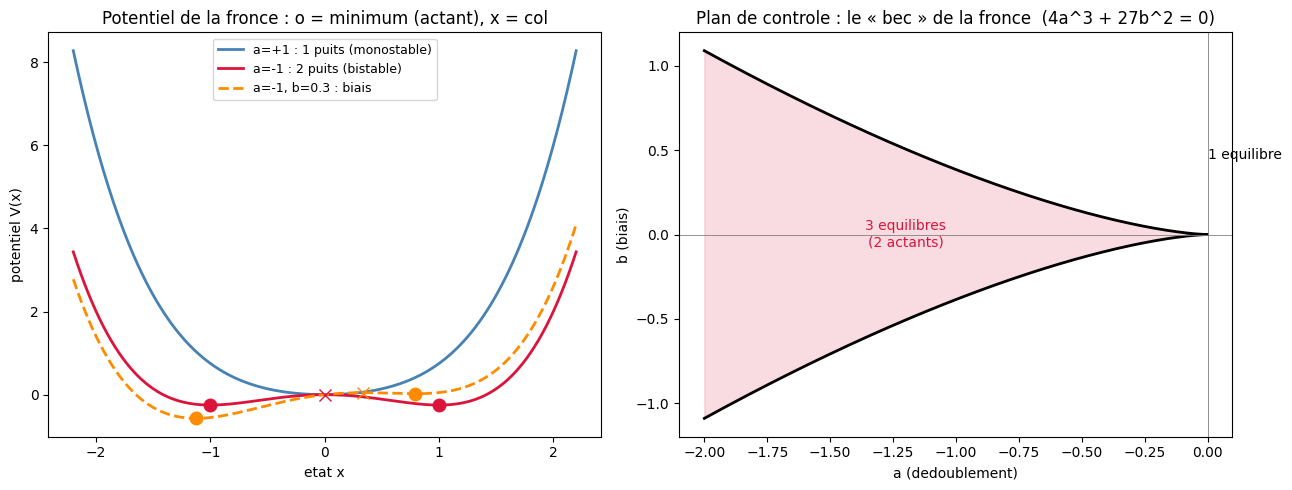

a=-1, b=0   -> equilibres : [(-1.0, 'stable'), (0.0, 'col'), (1.0, 'stable')]
a=+1, b=0   -> equilibres : [(0.0, 'stable')]
pli a a=-1 : b = +/-0.3849


In [2]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# (gauche) potentiel : monostable (a>0) vs bistable (a<0, deux puits)
x = np.linspace(-2.2, 2.2, 400)
axL.plot(x, cat.cusp_potential(x, a=1.0, b=0.0), color="steelblue", lw=2, label="a=+1 : 1 puits (monostable)")
axL.plot(x, cat.cusp_potential(x, a=-1.0, b=0.0), color="crimson", lw=2, label="a=-1 : 2 puits (bistable)")
axL.plot(x, cat.cusp_potential(x, a=-1.0, b=0.3), color="darkorange", lw=2, ls="--", label="a=-1, b=0.3 : biais")
for a_, b_, col in [(-1.0, 0.0, "crimson"), (-1.0, 0.3, "darkorange")]:
    for xe, st in cat.cusp_equilibria(a_, b_):
        axL.plot(xe, cat.cusp_potential(xe, a_, b_), "o" if st else "x", color=col, ms=9)
axL.set_xlabel("etat x"); axL.set_ylabel("potentiel V(x)")
axL.set_title("Potentiel de la fronce : o = minimum (actant), x = col"); axL.legend(fontsize=9)

# (droite) la courbe de bifurcation dans le plan de controle (a, b)
a_grid = np.linspace(-2.0, 0.4, 300)
b_inf, b_sup = cat.bifurcation_curve(a_grid)
axR.plot(a_grid, b_sup, color="black", lw=2); axR.plot(a_grid, b_inf, color="black", lw=2)
axR.fill_between(a_grid, b_inf, b_sup, where=~np.isnan(b_sup), color="crimson", alpha=0.15)
axR.text(-1.2, 0.0, "3 equilibres\n(2 actants)", ha="center", va="center", fontsize=10, color="crimson")
axR.text(0.15, 0.45, "1 equilibre", ha="center", fontsize=10)
axR.axhline(0, color="grey", lw=0.6); axR.axvline(0, color="grey", lw=0.6)
axR.set_xlabel("a (dedoublement)"); axR.set_ylabel("b (biais)")
axR.set_title("Plan de controle : le « bec » de la fronce  (4a^3 + 27b^2 = 0)")
plt.tight_layout(); plt.show()

print("a=-1, b=0   -> equilibres :", [(round(x,3), 'stable' if s else 'col') for x,s in cat.cusp_equilibria(-1,0)])
print("a=+1, b=0   -> equilibres :", [(round(x,3), 'stable' if s else 'col') for x,s in cat.cusp_equilibria(1,0)])
print(f"pli a a=-1 : b = +/-{cat.fold_lines(-1.0)[1]:.4f}")

## 2. Le metatheoreme : l'obstacle comme source de l'ontologie

Le **metatheoreme** de Thom (Ch.3, §B) dit, en substance : une forme saillante mobile dans un flux ne
peut donner naissance qu'a un **petit nombre de transitions generiques** — *debut*, *fin*, *ramification*,
*confluence*. La non-linearite $x^3$ joue le role de l'**obstacle** : c'est *lui* qui engendre la
multiplicite des bassins (la pluralite des « etres »). D'ou la formule *l'obstacle comme source de
l'ontologie*.

On le **mesure** directement : balayons $b$ a $a<0$ fixe et comptons les equilibres. Le nombre ne saute
qu'aux **plis**, et toujours de $\pm 2$ (un minimum et un col naissent ou s'annihilent ensemble). Le long
d'un chemin generique, il n'y a donc **exactement deux** transitions de comptage — ni plus, ni moins.

> **Lien Ch.2 (p.38)** : ces quatre transitions — debut, fin, ramification, confluence — sont, mot pour
> mot, celles dont Thom dit qu'elles *« symbolisent adequatement le contenu »* des premiers pivots du
> langage enfantin. La confluence devient d'abord une preposition (« chez »), puis un **verbe divalent**
> (Tesnière). Le comptage qu'on trace ici est la **proto-grammaire** mesuree.

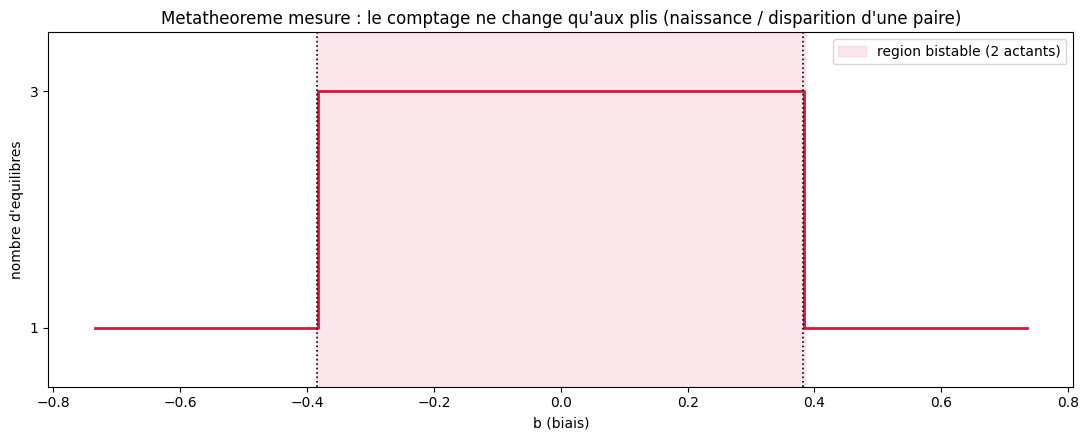

valeurs prises par le comptage : [1, 3]  (1 hors region, 3 dedans)
nombre de transitions de comptage le long du balayage : 2  (les deux plis)
les quatre types generiques de Thom : naissance (1->3), confluence/disparition (3->1).


In [3]:
a = -1.0
b_lo, b_hi = cat.fold_lines(a)
bs = np.linspace(b_lo - 0.35, b_hi + 0.35, 400)
counts = np.array([cat.count_equilibria(a, float(b)) for b in bs])
transitions = np.where(np.diff(counts) != 0)[0]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.step(bs, counts, where="mid", color="crimson", lw=2)
for j in transitions:
    ax.axvline(bs[j], color="black", ls=":", lw=1.2)
ax.axvspan(b_lo, b_hi, color="crimson", alpha=0.10, label="region bistable (2 actants)")
ax.set_yticks([1, 3]); ax.set_ylim(0.5, 3.5)
ax.set_xlabel("b (biais)"); ax.set_ylabel("nombre d'equilibres")
ax.set_title("Metatheoreme mesure : le comptage ne change qu'aux plis (naissance / disparition d'une paire)")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

print(f"valeurs prises par le comptage : {sorted(set(counts.tolist()))}  (1 hors region, 3 dedans)")
print(f"nombre de transitions de comptage le long du balayage : {len(transitions)}  (les deux plis)")
print("les quatre types generiques de Thom : naissance (1->3), confluence/disparition (3->1).")

### Exercice 1 — la fourche (pitchfork), section symetrique de la fronce

A $b=0$ (pas de biais), la fronce devient symetrique : c'est la **fourche**. Quand $a$ descend sous $0$,
l'unique equilibre $x=0$ se **dedouble** en deux minima symetriques (plus le col en $0$). Completez
`equilibres_fourche(a)` pour renvoyer la liste des positions d'equilibre **a $b=0$**, et observez le
dedoublement.

*Indices :* `cat.cusp_equilibria(a, 0.0)` renvoie la liste `(x*, stable)` ; on ne demande ici que les
positions `x*`. Le point critique (la « pointe » de la fourche) est en $a=0$.

In [4]:
def equilibres_fourche(a):
    """Positions d'equilibre de la fronce SYMETRIQUE (b=0), pour observer la fourche.
    Renvoyer None tant que l'exercice n'est pas complete."""
    # TODO etudiant : extraire les positions x* depuis cat.cusp_equilibria(a, 0.0)
    # return [x for x, _ in cat.cusp_equilibria(a, 0.0)]
    return None  # TODO

# Verification (a decommenter une fois complete) :
# for a in [0.5, 0.0, -0.5, -1.0]:
#     print(f"a={a:+.1f} -> equilibres (b=0) : {equilibres_fourche(a)}")
print("Exercice 1 a completer : observer le dedoublement de la fourche quand a passe sous 0.")

Exercice 1 a completer : observer le dedoublement de la fourche quand a passe sous 0.


## 3. Le lacet de predation : la scene actantielle mesuree

On ferme la strate 2 (morphogenese) et on **ouvre la strate 3** (agents). Le **lacet de predation** de
Thom (Ch.4, §C) est la scene actantielle canonique : deux actants (predateur, proie) comme deux minima,
et **deux franchissements** de la catastrophe le long d'un cycle — la **perception** (J : la proie entre
dans le champ du predateur) et la **capture** (K). On le mesure par un **cycle d'hysteresis** : a $a<0$
fixe, on fait varier le biais $b$ vers le haut puis vers le bas en suivant **adiabatiquement** le minimum
courant. Le systeme reste sur sa branche jusqu'a ce qu'elle disparaisse a un pli, puis **saute** :
c'est la catastrophe.

> **Lien Ch.2 (p.42)** : *« la signification d'un verbe peut etre symbolisee [...] comme une classe de
> chemins transverses a une hypersurface de catastrophe, decrivant la transmission brutale d'un etat
> stable 1 vers un etat stable 2 »*. La phrase transitive **SVO** *est* ce lacet. Et l'**aire** du cycle
> (non nulle) mesure l'**irreversibilite** : capture $\neq$ emission — la direction agent$\to$patient de
> la scene. C'est la *meme* fronce que la transition liquide-gaz de Van der Waals (note 8 du Ch.2) et que
> « la chaleur fait fondre la glace » (p.48).

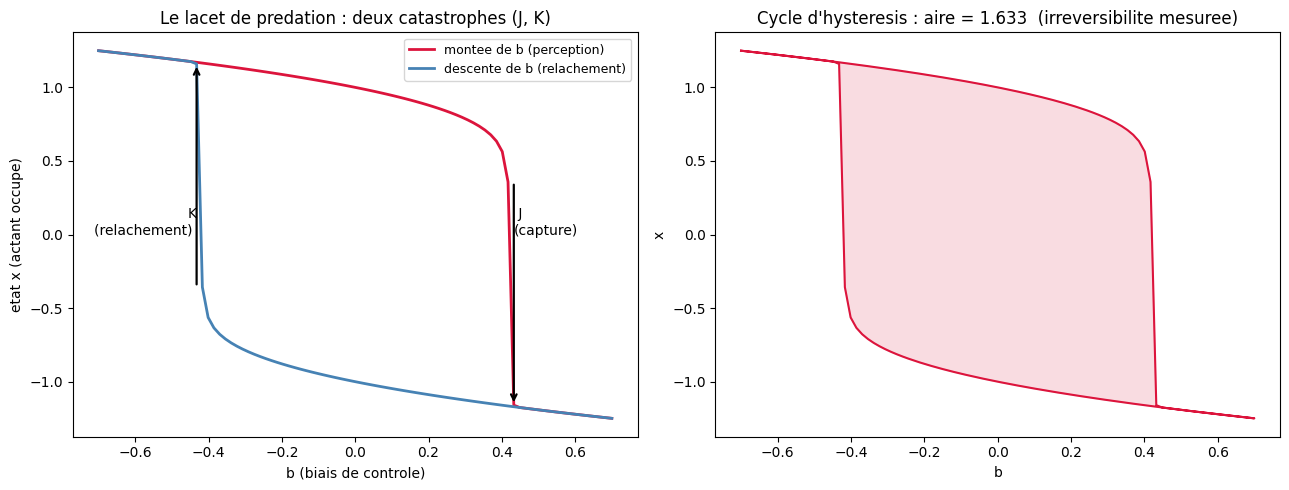

nombre de catastrophes le long du lacet : 2  (J = capture, K = relachement)
b aux franchissements : [0.433, -0.433]  (pli theorique : +/-0.385)
aire du cycle (hysteresis, signe = orientation) : +1.633  -> non nulle = scene orientee (SVO)


In [5]:
a = -1.0
b_up = np.linspace(-0.7, 0.7, 90)
b_path = np.concatenate([b_up, b_up[::-1]])               # aller (montee) puis retour (descente)
x0 = cat.cusp_equilibria(a, float(b_path[0]))[0][0]
xs = cat.hysteresis_loop(a, b_path, x_start=x0)
jumps = cat.loop_jumps(b_path, xs, threshold=0.5)
aire = float(trapz(xs, b_path))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))
n = len(b_up)
axL.plot(b_path[:n], xs[:n], color="crimson", lw=2, label="montee de b (perception)")
axL.plot(b_path[n:], xs[n:], color="steelblue", lw=2, label="descente de b (relachement)")
for j in jumps:
    axL.annotate("", xy=(b_path[j], xs[j]), xytext=(b_path[j], xs[j-1]),
                 arrowprops=dict(arrowstyle="->", color="black", lw=1.6))
if len(jumps) >= 1:
    axL.text(b_path[jumps[0]], 0.0, " J\n(capture)", fontsize=10)
if len(jumps) >= 2:
    axL.text(b_path[jumps[1]], 0.0, "K\n(relachement) ", fontsize=10, ha="right")
axL.set_xlabel("b (biais de controle)"); axL.set_ylabel("etat x (actant occupe)")
axL.set_title("Le lacet de predation : deux catastrophes (J, K)"); axL.legend(fontsize=9)

# le lacet ferme dans le plan (b, x) : son aire = hysteresis = irreversibilite
axR.fill(b_path, xs, color="crimson", alpha=0.15)
axR.plot(b_path, xs, color="crimson", lw=1.5)
axR.set_xlabel("b"); axR.set_ylabel("x")
axR.set_title(f"Cycle d'hysteresis : aire = {abs(aire):.3f}  (irreversibilite mesuree)")
plt.tight_layout(); plt.show()

print(f"nombre de catastrophes le long du lacet : {len(jumps)}  (J = capture, K = relachement)")
print(f"b aux franchissements : {[round(float(b_path[j]),3) for j in jumps]}  (pli theorique : +/-{b_hi:.3f})")
print(f"aire du cycle (hysteresis, signe = orientation) : {aire:+.3f}  -> non nulle = scene orientee (SVO)")

### Exercice 2 — l'hysteresis disparait a la pointe de la fronce

L'irreversibilite (l'aire du lacet) doit **s'effondrer** quand on rapproche $a$ de $0$ : a la pointe
$a=0$, les deux puits fusionnent, il n'y a plus de bistabilite, donc plus de saut — la scene actantielle
**se degrade** en transition lisse. Completez `aire_lacet(a)` qui renvoie l'aire (valeur absolue) du
cycle d'hysteresis pour un $a<0$ donne, et verifiez la decroissance vers $0$.

*Indices :* reproduire le balayage `b_path` de la section 3, appeler `cat.hysteresis_loop(a, b_path, ...)`,
puis `abs(trapz(xs, b_path))`. Adapter l'amplitude du balayage de $b$ a la taille du pli `cat.fold_lines(a)`.

In [6]:
def aire_lacet(a):
    """Aire (valeur absolue) du cycle d'hysteresis pour un a < 0 donne.
    Mesure l'irreversibilite de la scene actantielle. Renvoyer None tant que non complete."""
    # TODO etudiant :
    # bf = cat.fold_lines(a)
    # if bf is None: return 0.0            # a >= 0 : pas de bistabilite, pas d'hysteresis
    # b_up = np.linspace(-2*bf[1], 2*bf[1], 90)
    # b_path = np.concatenate([b_up, b_up[::-1]])
    # xs = cat.hysteresis_loop(a, b_path, x_start=cat.cusp_equilibria(a, float(b_path[0]))[0][0])
    # return abs(float(trapz(xs, b_path)))
    return None  # TODO

# Verification (a decommenter) :
# for a in [-1.0, -0.6, -0.3, -0.1]:
#     print(f"a={a:+.2f} -> aire du lacet = {aire_lacet(a)}")
print("Exercice 2 a completer : l'hysteresis (aire) s'effondre quand a -> 0 (degenerescence).")

Exercice 2 a completer : l'hysteresis (aire) s'effondre quand a -> 0 (degenerescence).


## 4. Le representant interne `p_hat` : anticiper la proie

Thom (Ch.4) place dans l'etat metabolique du predateur un **representant interne** de la proie, qui
*« anticipe »* la proie reelle (et Ch.2, p.50 : on se deplace en *« anticipant la trajectoire de
l'objet »*). C'est le germe d'une **proto-representation** — et le pont, *sous caveat*, vers la strate 3
(agents) et, plus loin, l'explicabilite.

On le mesure **sans complaisance**, sur un banc durci en trois directions :

1. **Trois familles de trajectoires** aux cinematiques opposees : le *sinus bruite* (inertie lisse,
   exploitable par un modele de vitesse), la *marche aleatoire a derive* (le bruit domine la derive :
   la vitesse instantanee n'est que du bruit amplifie), le *creneau* (discontinuites : tout modele de
   vitesse sur-reagit au saut).
2. **Trois baselines adverses**, reellement calculees : la *persistance* (suit sans modele), la
   *moyenne mobile* (lisse mais retarde), et un *AR(1)* dont le coefficient est ajuste **sur la serie
   complete** (in-sample) — un adversaire volontairement avantage, pas un homme de paille.
3. **Deux metriques separees**, jamais agregees : (a) le **pic de correlation croisee** (a quel
   decalage l'estimateur correle-t-il le mieux avec la proie ? lag > 0 = il regarde vers le futur) et
   (b) l'**erreur a horizon fixe** `lead`. Les deux peuvent diverger — et divergent reellement
   ci-dessous.

**Clause de falsifiabilite** : `p_hat` doit battre la **meilleure** des trois baselines, famille par
famille (le gain se reporte par famille, jamais en moyenne). S'il ne gagne pas sur au moins 2 familles
sur 3, le verdict honnete est *« avantage regime-dependant »* — pas *« p_hat anticipe »*. La ou
`p_hat` echoue doit rester **visible** dans la sortie.

=== sinus ===
  p_hat           erreur@4 = 0.0554   pic_lag = +3
  persistance     erreur@4 = 0.1010   pic_lag = -1
  moyenne_mobile  erreur@4 = 0.1281   pic_lag = -2
  ar1             erreur@4 = 0.0684   pic_lag = +0
  -> p_hat BAT la meilleure baseline (ar1 : 0.0684) | 5/5 graines, marge +0.0120 +/- 0.0020
=== derive ===
  p_hat           erreur@4 = 0.0516   pic_lag = +0
  persistance     erreur@4 = 0.0453   pic_lag = -1
  moyenne_mobile  erreur@4 = 0.0483   pic_lag = -1
  ar1             erreur@4 = 0.0354   pic_lag = +0
  -> p_hat PERD contre la meilleure baseline (ar1 : 0.0354) | 0/5 graines, marge -0.0198 +/- 0.0025
=== creneau ===
  p_hat           erreur@4 = 0.2993   pic_lag = +0
  persistance     erreur@4 = 0.2210   pic_lag = -1
  moyenne_mobile  erreur@4 = 0.2184   pic_lag = -2
  ar1             erreur@4 = 0.1691   pic_lag = +0
  -> p_hat PERD contre la meilleure baseline (ar1 : 0.1691) | 0/5 graines, marge -0.1369 +/- 0.0158


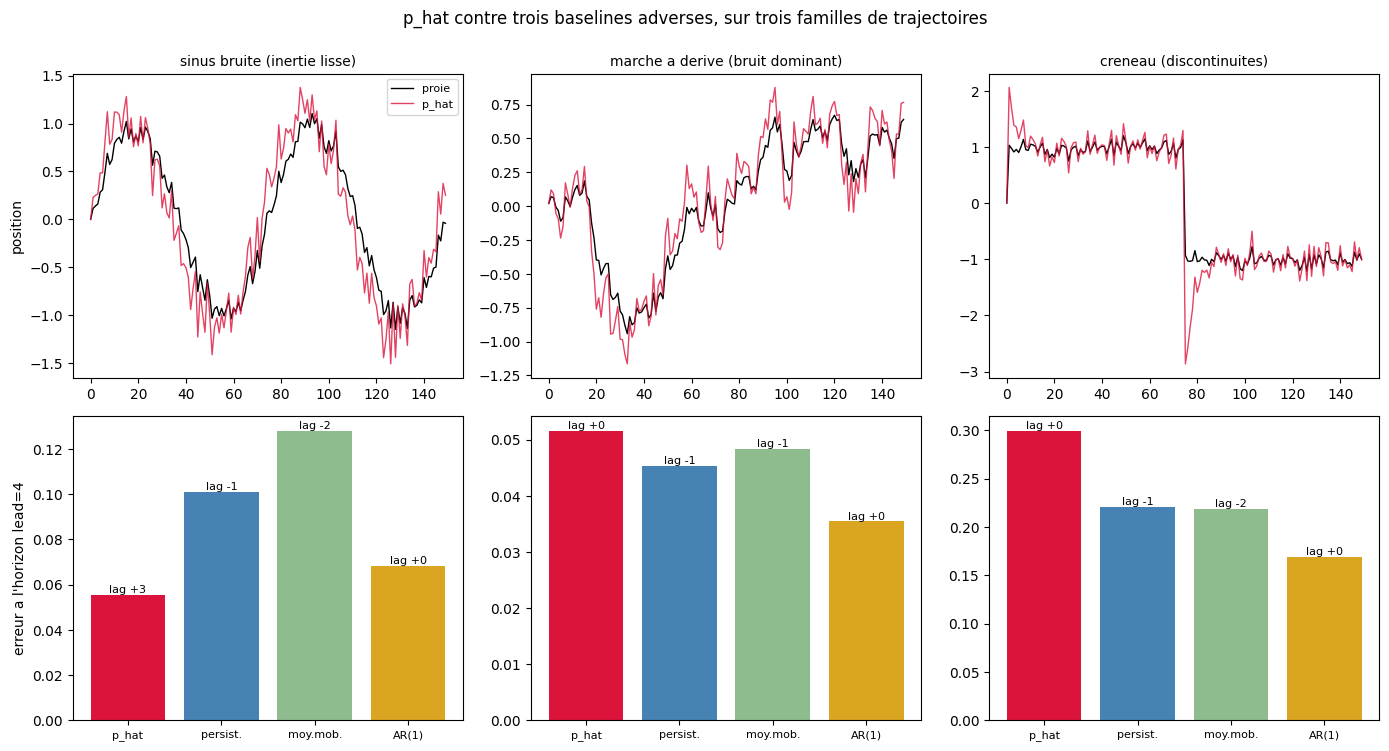


Verdict : p_hat bat la meilleure baseline sur 1/3 familles (critere de la clause : >= 2/3 pour crediter l'anticipation)
-> avantage REGIME-DEPENDANT : p_hat anticipe la ou l'inertie est exploitable (sinus),
   pas sur la derive bruitee ni sur les discontinuites. L'echec reste visible ci-dessus.


In [7]:
familles = ["sinus", "derive", "creneau"]
ETIQUETTES = {"sinus": "sinus bruite (inertie lisse)",
              "derive": "marche a derive (bruit dominant)",
              "creneau": "creneau (discontinuites)"}
ESTIMATEURS = ["p_hat", "persistance", "moyenne_mobile", "ar1"]
LEAD = 4
GRAINES = [0, 1, 7, 42, 99]                      # robustesse multi-graines

# --- banc principal (graine GRAINE) : deux metriques SEPAREES, par famille ---
proies, rapports = {}, {}
for famille in familles:
    proie = cat.prey_trajectory(famille, n_steps=300, noise=0.10,
                                rng=np.random.default_rng(GRAINE))
    proies[famille] = proie
    rapports[famille] = cat.anticipation_report(proie, lead=LEAD, alpha=0.25,
                                                window=5, max_lag=10)

# --- robustesse : marge de p_hat contre la MEILLEURE baseline, 5 graines ---
marges = {famille: [] for famille in familles}
for graine in GRAINES:
    for famille in familles:
        proie_g = cat.prey_trajectory(famille, n_steps=300, noise=0.10,
                                      rng=np.random.default_rng(graine))
        rep = cat.anticipation_report(proie_g, lead=LEAD)
        best = min(v["erreur"] for nom, v in rep.items() if nom != "p_hat")
        marges[famille].append(best - rep["p_hat"]["erreur"])    # > 0 : p_hat gagne

# --- tableau par famille : erreur@lead ET pic de correlation, jamais agreges ---
victoires = {}
for famille in familles:
    rep = rapports[famille]
    print(f"=== {famille} ===")
    for nom in ESTIMATEURS:
        print(f"  {nom:15s} erreur@{LEAD} = {rep[nom]['erreur']:.4f}   pic_lag = {rep[nom]['pic_lag']:+d}")
    best_nom, best = min(((nom, rep[nom]["erreur"]) for nom in ESTIMATEURS[1:]),
                         key=lambda nv: nv[1])
    m = np.array(marges[famille])
    victoires[famille] = int((m > 0).sum())
    verdict = "BAT" if rep["p_hat"]["erreur"] < best else "PERD contre"
    print(f"  -> p_hat {verdict} la meilleure baseline ({best_nom} : {best:.4f})"
          f" | {victoires[famille]}/{len(GRAINES)} graines, marge {m.mean():+.4f} +/- {m.std():.4f}")

# --- figure : trajectoires + p_hat (haut), erreurs des 4 estimateurs (bas) ---
COULEURS = {"p_hat": "crimson", "persistance": "steelblue",
            "moyenne_mobile": "darkseagreen", "ar1": "goldenrod"}
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5))
for j, famille in enumerate(familles):
    proie = proies[famille]
    p_hat = cat.constant_velocity_tracker(proie, lead=LEAD, alpha=0.25)
    ax = axes[0, j]
    ax.plot(proie[:150], color="black", lw=1.0, label="proie")
    ax.plot(p_hat[:150], color="crimson", lw=1.0, alpha=0.8, label="p_hat")
    ax.set_title(ETIQUETTES[famille], fontsize=10)
    if j == 0:
        ax.set_ylabel("position"); ax.legend(fontsize=8)
    ax = axes[1, j]
    rep = rapports[famille]
    barres = ax.bar(range(len(ESTIMATEURS)),
                    [rep[nom]["erreur"] for nom in ESTIMATEURS],
                    color=[COULEURS[nom] for nom in ESTIMATEURS])
    for barre, nom in zip(barres, ESTIMATEURS):      # pic_lag annote sur chaque barre
        ax.text(barre.get_x() + barre.get_width() / 2, barre.get_height(),
                f"lag {rep[nom]['pic_lag']:+d}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(range(len(ESTIMATEURS)))
    ax.set_xticklabels(["p_hat", "persist.", "moy.mob.", "AR(1)"], fontsize=8)
    if j == 0:
        ax.set_ylabel(f"erreur a l'horizon lead={LEAD}")
fig.suptitle("p_hat contre trois baselines adverses, sur trois familles de trajectoires", y=0.995)
plt.tight_layout(); plt.show()

n_gagnees = sum(v > len(GRAINES) // 2 for v in victoires.values())
print(f"\nVerdict : p_hat bat la meilleure baseline sur {n_gagnees}/{len(familles)} familles"
      f" (critere de la clause : >= 2/3 pour crediter l'anticipation)")
print("-> avantage REGIME-DEPENDANT : p_hat anticipe la ou l'inertie est exploitable (sinus),"
      "\n   pas sur la derive bruitee ni sur les discontinuites. L'echec reste visible ci-dessus.")

### Verdict sans complaisance : un avantage regime-dependant

Le banc durci renverse la conclusion trop confortable d'un banc a une seule famille
(« `p_hat` bat la persistance ») :

- **Sinus bruite** — `p_hat` **gagne** contre les trois baselines (erreur 0.055 contre 0.068 pour le
  meilleur adversaire, l'AR(1)), et c'est robuste : 5/5 graines, marge +0.012 ± 0.002. Son pic de
  correlation a **lag +3** confirme qu'il correle avec le futur de la proie.
- **Marche a derive** — `p_hat` **perd** (0/5 graines, marge −0.020 ± 0.003) : le bruit domine la
  derive, et la vitesse lissee n'est que du bruit amplifie. C'est aussi la famille ou les **deux
  metriques divergent** : `p_hat` a le pic de correlation le moins retarde (lag +0, contre −1 pour la
  persistance) **tout en ayant la pire erreur des quatre estimateurs** (0.052). Un pic de correlation
  flatteur ne prouve pas un contenu predictif — d'ou l'obligation de reporter les deux metriques
  separement.
- **Creneau** — `p_hat` **perd nettement** (0/5 graines, marge −0.137 ± 0.016) : a chaque saut, le
  modele de vitesse sur-reagit et extrapole dans le vide.

Le verdict honnete est donc : **l'anticipation de `p_hat` est regime-dependante** — reelle la ou la
trajectoire a une inertie exploitable, illusoire ailleurs. C'est ce que la clause de falsifiabilite
exigeait de rendre visible ; un banc a une seule famille l'aurait masque. L'AR(1), ajuste in-sample sur
la serie complete, reste l'adversaire le plus dur partout — le battre sur le sinus n'en a que plus de
valeur.

### Exercice 3 — *sans complaisance* : le compromis de l'anticipation

L'anticipation n'est pas gratuite. La vitesse **brute** (`alpha=1`, sans lissage) amplifie le bruit
d'observation d'un facteur `lead` : en milieu bruite, `p_hat` peut alors devenir **pire** que la simple
persistance. C'est un **compromis biais-variance** qu'il faut *mesurer*, pas masquer. Completez
`gain_anticipation(bruit, alpha)` : le gain = erreur(persistance) − erreur(`p_hat`) a l'horizon `LEAD`
(positif = `p_hat` utile), et observez qu'il **chute** quand `alpha -> 1` sur une proie bruitee.

*Indices :* regenerer une proie `sin + bruit * randn` (graine fixe), construire `p_hat` avec l'`alpha`
donne et le `suiveur`, puis comparer `cat.lead_error(..., LEAD)`.

In [8]:
def gain_anticipation(bruit, alpha):
    """Gain de l'anticipation : lead_error(persistance) - lead_error(p_hat), a l'horizon LEAD.
    Positif = p_hat utile ; chute vers <=0 si alpha=1 (vitesse brute) sur proie bruitee.
    Renvoyer None tant que non complete."""
    # TODO etudiant :
    # g = np.random.default_rng(GRAINE)
    # y = np.sin(t) + bruit * g.standard_normal(T)
    # ph = cat.constant_velocity_tracker(y, lead=LEAD, alpha=alpha)
    # su = cat.persistence_tracker(y)
    # return cat.lead_error(su, y, LEAD) - cat.lead_error(ph, y, LEAD)
    return None  # TODO

# Verification (a decommenter) :
# for al in [0.25, 0.5, 1.0]:
#     print(f"bruit=0.20, alpha={al:.2f} -> gain anticipation = {gain_anticipation(0.20, al)}")
print("Exercice 3 a completer : mesurer le compromis biais-variance (alpha=1 degrade en milieu bruite).")

Exercice 3 a completer : mesurer le compromis biais-variance (alpha=1 degrade en milieu bruite).


## 5. *Sans complaisance* : la catastrophe n'est reelle que hors degenerescence

La tentation serait de balayer $b$ **sans verifier $a<0$** et d'appeler « hysteresis » la courbe obtenue.
Or a $a \geq 0$ il n'y a **qu'un** equilibre : le suivi est **continu**, **zero** saut, aire **nulle**.
Annoncer une « scene actantielle » dans ce regime, c'est fabriquer un **phantome** — l'equivalent, pour
les catastrophes, du « probleme degenere » (un A\* sur graphe a cout uniforme, ou un Z3 sur une contrainte
qu'un `if` resout). On le **mesure** : meme balayage, deux regimes.

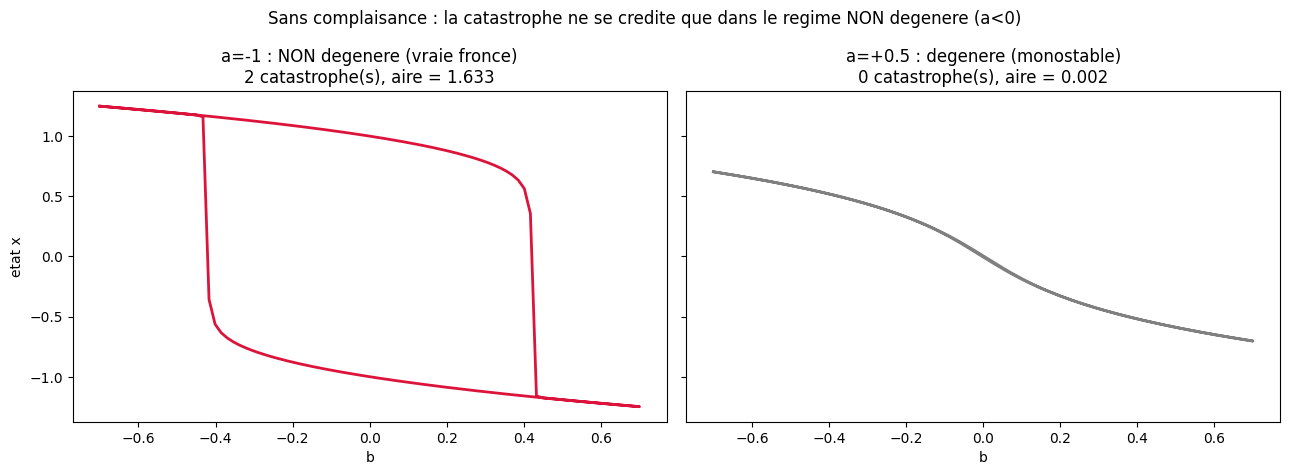

a=-1.0 : 2 saut(s), aire=1.633, bistable=True
a=+0.5 : 0 saut(s), aire=0.002, bistable=False


In [9]:
b_up = np.linspace(-0.7, 0.7, 90); b_path = np.concatenate([b_up, b_up[::-1]])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, (a_, ttl) in zip(axes, [(-1.0, "a=-1 : NON degenere (vraie fronce)"), (0.5, "a=+0.5 : degenere (monostable)")]):
    xs = cat.hysteresis_loop(a_, b_path, x_start=cat.cusp_equilibria(a_, float(b_path[0]))[0][0])
    nj = len(cat.loop_jumps(b_path, xs, threshold=0.5))
    ar = abs(float(trapz(xs, b_path)))
    ax.plot(b_path, xs, color="crimson" if a_ < 0 else "grey", lw=2)
    ax.set_xlabel("b"); ax.set_title(f"{ttl}\n{nj} catastrophe(s), aire = {ar:.3f}")
axes[0].set_ylabel("etat x")
plt.suptitle("Sans complaisance : la catastrophe ne se credite que dans le regime NON degenere (a<0)")
plt.tight_layout(); plt.show()

for a_ in (-1.0, 0.5):
    xs = cat.hysteresis_loop(a_, b_path, x_start=cat.cusp_equilibria(a_, float(b_path[0]))[0][0])
    print(f"a={a_:+.1f} : {len(cat.loop_jumps(b_path, xs, 0.5))} saut(s), aire={abs(float(trapz(xs,b_path))):.3f}, bistable={cat.in_bistable_region(a_, 0.0)}")

## 6. Portee et barreaux : du gradient basse-dimension aux systemes discrets

**Le caveat, droit.** La theorie des catastrophes classe les singularites des **dynamiques gradient de
basse dimension** (les 7 catastrophes elementaires couvrent $\leq 4$ parametres de controle). Un LLM
n'est ni gradient (au sens dynamique), ni de basse dimension. **Appliquer la fronce litteralement a un
reseau de milliards de parametres serait une categorie-erreur.** Thom lui-meme est explicitement
**non-predictif** (Ch.2, p.51). Ce notebook fournit donc des **designs de mesure**, pas un modele de LLM.

**Mais le pont n'est pas sans barreaux.** Le passage « peu d'attracteurs continus -> multitude d'unites
discretes a couplage controle » est *deja* chez Thom : c'est sa transition animal->humain (Ch.2, p.35).
Les barreaux intermediaires, dans nos series :

| Barreau | Ou | Le passage qu'il instancie |
|---|---|---|
| **0. Linguistique de Thom** | Ch.2 & Ch.8 | preuve d'existence : grammaire discrete <- morphodynamique continue |
| **1. Neurosymbolique** | serie neurosymbolique | l'ingenierie du couplage continu <-> symbolique discret |
| **2. Lean** | serie Lean + harnais prover | l'objet discret de haute dimension (preuve = arbre), deja couple a du continu (selection de premisses guidee) — Ch.2 p.46 : *« la generativite interne au langage formel, sur laquelle l'homme n'a plus de prise une fois fixees les conditions initiales »* |
| **3. Auto-encodeurs epars (SAE)** | cible lointaine | trouver le squelette discret de *features* dans la variete continue d'activations — *le meme geste que Thom*, a l'echelle, **sans** la garantie basse-dimension |

Une brique candidate de veille a ete deposee (#4653) : les **arbres d'EML** (analogue *continu* de portes
NAND), substrat possiblement « interpretable-par-construction » — a tester, **conjecture etiquetee comme
telle**, et **hors ICT** (materiel serie neurosymbolique).

**Suite immediate de la strate 2/3**, chaque metaphore restant attachee a une mesure :
[ICT-11](#) (profils d'agence causale aux echelles micro/meso/macro) et **ICT-Synthese** (reunir $\Phi$,
trajectoires, bassins, transitions, reparation, agence). Discipline de la serie : *ne pas ouvrir cinq
fronts a la fois*.

## Conclusion — la grammaire tenue par la mesure

On a tresse les deux fils, et le chapitre 2 de Thom les a noues a sa theorie du langage :

| Le fil metaphorique (Thom) | Le fil de la mesure (ICT-10) |
|---|---|
| *l'obstacle engendre les etres* (metatheoreme) | le comptage d'equilibres ne change qu'aux **plis** : exactement 2 transitions |
| les 4 transitions = pivots du langage enfantin (Ch.2 p.38) | naissance (1->3) et confluence/disparition (3->1), **mesurees** |
| la phrase transitive SVO = chemin transverse a une catastrophe (Ch.2 p.42) | le **lacet de predation** : 2 catastrophes (J, K), aire non nulle |
| capture $\neq$ emission : la scene est orientee | l'**aire signee** du cycle d'hysteresis = irreversibilite mesuree |
| *anticiper la trajectoire de l'objet* (Ch.2 p.50) | `p_hat` : avantage **regime-dependant** — bat 3 baselines adverses sur trajectoire lisse (5/5 graines), perd sur derive et creneau |
| « c'est une catastrophe » | **piege** : hors regime $a<0$, zero saut, aire nulle — phantome degenere |

**Aucune image de Thom n'a ete declaree : chacune a ete mesuree** sur la fronce canonique. La strate 2
(morphogenese) se referme sur son squelette catastrophique ; la strate 3 (agents) s'ouvre sur une scene
actantielle et un representant interne dont l'anticipation est mesuree — et bornee a son regime de validite. Le pont vers les LLM reste **lointain et a barreaux**
(section 6) — mais la regle ne change pas : *une metaphore n'entre dans ICT que lorsqu'elle est attachee a
une mesure.*